In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import rc
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
mpl.rcParams.update(mpl.rcParamsDefault)

rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
mpl.rcParams['savefig.dpi'] = 1200
mpl.rcParams['text.usetex'] = True  # not really needed

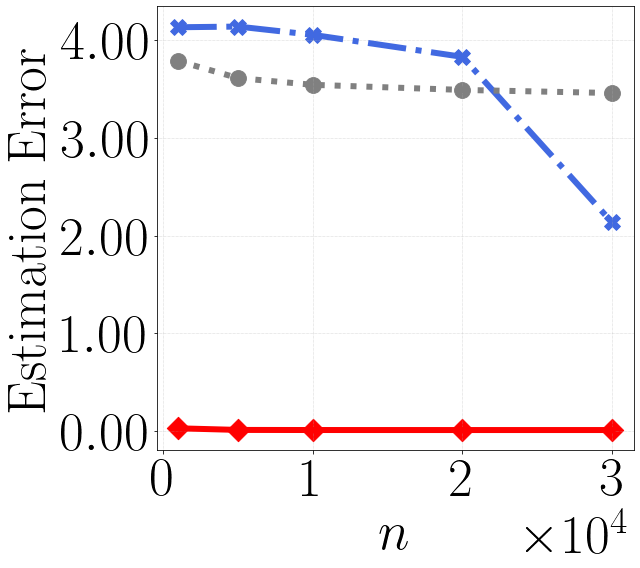

In [3]:
# observed entries
d1 = [1000, 5000, 10000, 20000, 30000]
alt_GD = np.array([4.1352606, 4.1422887, 4.0574770, 3.8321424, 2.1367757])
softimpute_als = np.array([3.7888470, 3.6143648, 3.5455268, 3.4931482, 3.4613315])
nuclear_reg = np.array([3.9230829, 2.5751333, 3.2846257, 2.6972797, 2.2170639])
iipw_1 = np.array([3.8866611, 3.4643601, 3.0032921, 1.7050502, 1.7050502])
#iipw = np.array([1.5034147, 0.0456746, 0.0146587, 0.0079182, 0.0071486])
iipw = np.array([0.0255003, 0.0090196, 0.0079685, 0.0077329, 0.0078302])

f, ax = plt.subplots(figsize=(9,8))

plt.plot(d1, alt_GD, lw=6, color='royalblue',ls="dashdot" )
plt.plot(d1, softimpute_als, lw=6, color='grey', ls="dotted")
#plt.plot(d1, nuclear_reg, lw=3, color='gold', ls="dashed")
plt.plot(d1, iipw, color='red',lw=6)

plt.scatter(d1, alt_GD, s=250, color='royalblue', label=r"$\mathrm{Alternating~GD}$", marker="X")
plt.scatter(d1, softimpute_als, s=250, color='grey', label=r"$\mathrm{SoftImpute~ALS}$", marker="o")
#plt.scatter(d1, nuclear_reg, s=100, color='gold', label=r"$\mathrm{Nuclear~norm~reg.}$")
plt.scatter(d1, iipw, s=250, color='red', label=r"$\mathrm{Algorithm~1}$", marker="D")

plt.xlabel(r"$n$", fontsize=54)
plt.ylabel(r"$\mathrm{Recovery~Error}$", fontsize=54)

xticks = [0, 10000, 20000, 30000]
plt.xticks(xticks, fontsize=54)
plt.ticklabel_format(style='sci', scilimits=(0,0), axis='x')
plt.yticks([0,1,2,3,4],[r'$\mathrm{0.00}$', r'$\mathrm{1.00}$', r'$\mathrm{2.00}$', r'$\mathrm{3.00}$', r'$\mathrm{4.00}$'],fontsize=54)
ax.xaxis.get_offset_text().set_fontsize(54)

#plt.legend(fontsize=36, loc='upper right', bbox_to_anchor=(1.02, 0.5))

plt.grid(lw=0.5, ls=":")
plt.tight_layout()
plot_name = f"five_entries_per_row_err.pdf"
plt.savefig(plot_name, bbox_inches='tight', format="pdf", dpi=1200)

plt.show()
plt.close()

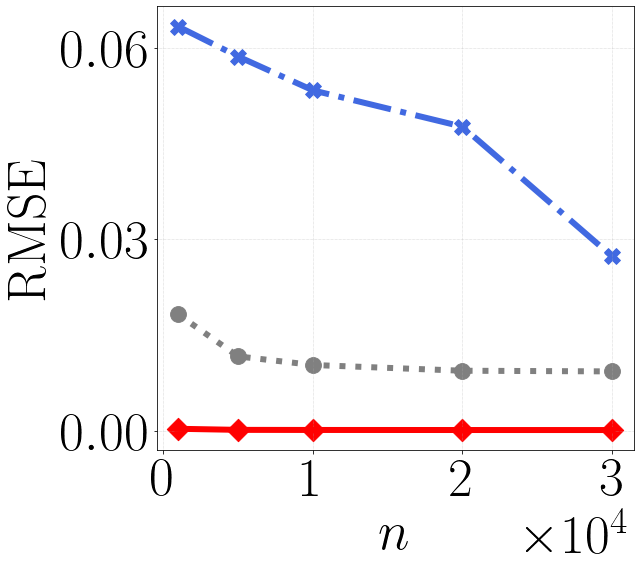

In [4]:
# observed entries
title = r'$\mathrm{Synthetic~(2~obervations)}$'
alt_GD_rmse = np.array([0.0633221, 0.0586335, 0.0533341, 0.0476407, 0.0273434])
softimpute_als_rmse = np.array([0.0182200, 0.0116478, 0.0103066, 0.0094056, 0.0093011])
nuclear_reg_rmse = np.array([0.0275115, 0.0071384, 0.0081713, 0.0054233, 0.0039521])
iipw_1_rmse = np.array([0.0256448, 0.0110687, 0.0072250, 0.0041964, 0.0028500])
#iipw_rmse = np.array([0.0112377, 0.0002450, 0.0001350, 0.0001205, 0.0001136])
iipw_rmse = np.array([0.0003102, 0.0001417, 0.0001271, 0.0001174, 0.0001132])

f, ax = plt.subplots(figsize=(9,8))

plt.plot(d1, alt_GD_rmse, lw=6, color='royalblue',ls="dashdot")
plt.plot(d1, softimpute_als_rmse, lw=6, color='grey', ls="dotted")
#plt.plot(d1, nuclear_reg_rmse, lw=3, color='gold', ls="dashed")
plt.plot(d1, iipw_rmse, color='red', lw=6)

plt.scatter(d1, alt_GD_rmse, s=250, color='royalblue', label=r"$\mathrm{Alternating~GD}$", marker="X")
plt.scatter(d1, softimpute_als_rmse, s=250, color='grey', label=r"$\mathrm{SoftImpute~ALS}$", marker="o")
#plt.scatter(d1, nuclear_reg_rmse, s=100, color='gold', label=r"$\mathrm{Nuclear~norm~reg.}$")
plt.scatter(d1, iipw_rmse, s=250, color='red', label=r"$\mathrm{Algorithm~2}$", marker="D")

plt.xlabel(r"$n$", fontsize=54)
plt.ylabel(r"$\mathrm{RMSE}$", fontsize=54)

#plt.yticks([0.3, 0.6, 0.9], fontsize=40)
plt.yticks([0, 0.03, 0.06], fontsize=54)
#plt.legend(fontsize=36, loc='upper right', bbox_to_anchor=(0.77, 0.71))

xticks = [0, 10000, 20000, 30000]
plt.xticks(xticks, fontsize=54)
plt.ticklabel_format(style='sci', scilimits=(0,0), axis='x')
ax.xaxis.get_offset_text().set_fontsize(54)
#plt.legend(fontsize=30, loc='upper right')
plt.grid(lw=0.5, ls=":")
plt.tight_layout()
plot_name = f"five_entries_per_row_rmse.pdf"
plt.savefig(plot_name, bbox_inches='tight', format="pdf", dpi=1200)

plt.show()
plt.close()

/var/folders/j2/0zz11rkn3z7dlcnhcy6cjnbw0000gn/T/ipykernel_9002/2550226615.py:38: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


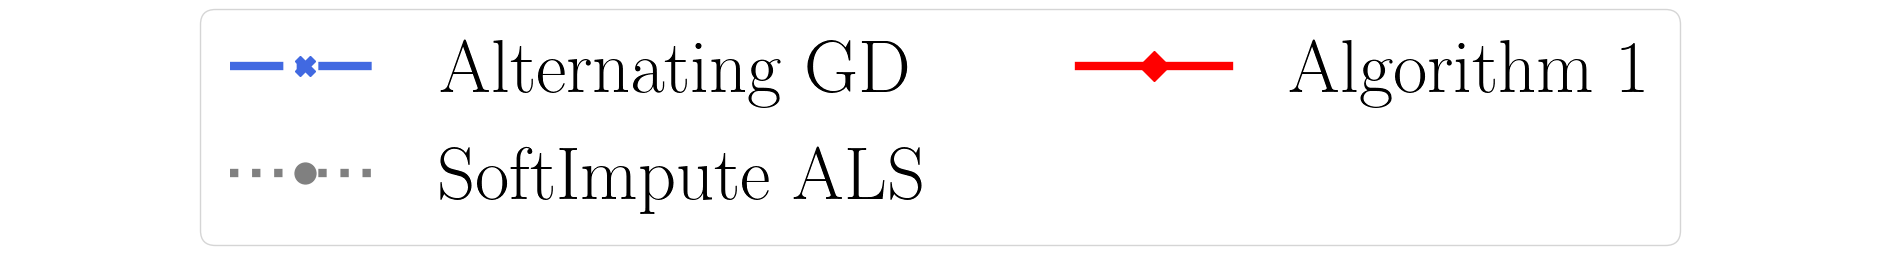

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import rc
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator
import json

mpl.rcParams.update(mpl.rcParamsDefault)

rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
mpl.rcParams['savefig.dpi'] = 1200
mpl.rcParams['text.usetex'] = True  # not really needed
from matplotlib.lines import Line2D

# Create a figure and remove axes
fig, ax = plt.subplots(figsize=(24, 0.5))
fig.patch.set_visible(False)
ax.axis('off')

# Define dummy legend handles
legend_elements = [
    Line2D([0], [0], color='royalblue', lw=6, ls='dashdot', marker='X', markersize=15, label=r"$\mathrm{Alternating~GD}$"),
    Line2D([0], [0], color='grey', lw=6, ls='dotted', marker='o', markersize=15, label=r"$\mathrm{SoftImpute~ALS}$"),
    Line2D([0], [0], color='red', lw=6, marker='D', markersize=15, label=r"$\mathrm{Algorithm~1}$")
]
# Create the legend
legend = ax.legend(
    handles=legend_elements,
    loc='center',
    frameon=True,       # remove legend box border
    fontsize=54,
    ncol=2              # or more columns if needed
)

# Adjust layout and save
plt.tight_layout()
plt.savefig("legend_app_alg1.pdf", bbox_inches='tight', dpi=300)
plt.show()

/var/folders/j2/0zz11rkn3z7dlcnhcy6cjnbw0000gn/T/ipykernel_9002/4130436195.py:38: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


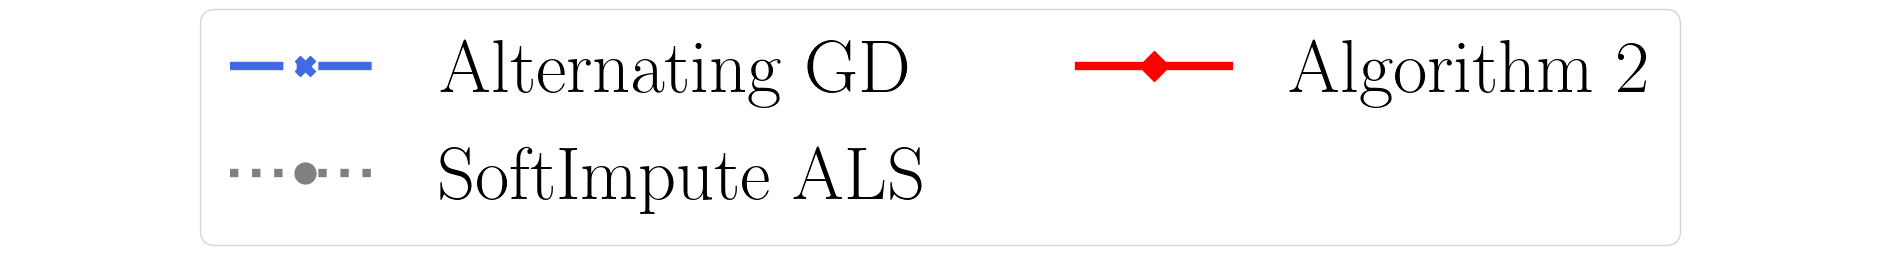

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import rc
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator
import json

mpl.rcParams.update(mpl.rcParamsDefault)

rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
mpl.rcParams['savefig.dpi'] = 1200
mpl.rcParams['text.usetex'] = True  # not really needed
from matplotlib.lines import Line2D

# Create a figure and remove axes
fig, ax = plt.subplots(figsize=(24, 0.5))
fig.patch.set_visible(False)
ax.axis('off')

# Define dummy legend handles
legend_elements = [
    Line2D([0], [0], color='royalblue', lw=6, ls='dashdot', marker='X', markersize=15, label=r"$\mathrm{Alternating~GD}$"),
    Line2D([0], [0], color='grey', lw=6, ls='dotted', marker='o', markersize=15, label=r"$\mathrm{SoftImpute~ALS}$"),
    Line2D([0], [0], color='red', lw=6, marker='D', markersize=15, label=r"$\mathrm{Algorithm~2}$")
]
# Create the legend
legend = ax.legend(
    handles=legend_elements,
    loc='center',
    frameon=True,       # remove legend box border
    fontsize=54,
    ncol=2              # or more columns if needed
)

# Adjust layout and save
plt.tight_layout()
plt.savefig("legend_app_alg2.pdf", bbox_inches='tight', dpi=300)
plt.show()